# 04 - Genomic Feature Selection + XAI

**Owner:** Janhavi

---

### Purpose
- Perform feature selection on genomic variables.
- Train an explainable model for feature importance.
- Generate SHAP-based explanations for genomic features.
- Save feature selector and importance scores.

### Input
| File | Path |
|------|------|
| Processed dataset | `data/processed/final_dataset.csv` |

### Outputs
| File | Path | Description |
|------|------|-------------|
| Feature selector | `models/feature_selector.pkl` | Selected HistGradientBoostingClassifier (HistGB) feature-selector model |
| Feature importance | `results/genomic_feature_importance.csv` | Feature names + importance scores |

### Data Integrity and Novelty Boundary
The genomic columns in the official `final_dataset.csv` are global aggregates. They are not sample-level strain assignments, and this notebook does not create synthetic genomic variation or infer farm-to-sample mappings. Constant-feature findings are reported as a limitation. The reproducible temporal and leakage audit is generated by `scripts/validation_audit.py`, using only earlier official records for each walk-forward training fold.

### For Colab Users
```python
# After training, save and download:
import joblib
joblib.dump(selector, "feature_selector.pkl")
# Then upload .pkl to models/ and .csv to results/ on GitHub
```

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
import shap

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
# If running in Colab, upload final_dataset.csv or mount drive
# DATA_PATH = "final_dataset.csv"          # Colab
DATA_PATH = os.path.join("..", "data", "processed", "final_dataset.csv")  # Local

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11657, 22)


,country,year,production,temperature_celsius,precip_mm,humidity,water_Salinity (ppt),water_pH,water_SecchiDepth (m),water_WaterDepth (m),...,genomic_GC_Content_global_mean,genomic_AT_Content_global_mean,genomic_Sequence_Length_global_mean,genomic_Num_A_global_mean,genomic_Num_T_global_mean,genomic_Num_C_global_mean,genomic_Num_G_global_mean,genomic_kmer_3_freq_global_mean,genomic_Mutation_Flag_global_mean,genomic_Disease_Risk_global_mode
0,Afghanistan,1969,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
1,Afghanistan,1970,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
2,Afghanistan,1971,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
3,Afghanistan,1972,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
4,Afghanistan,1973,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High


In [3]:
# ============================================================
# CREATE PRODUCTION CATEGORY
# ============================================================
# Create 3 production categories (Low, Medium, High) using quantile-based binning
df['Production_Category'] = pd.qcut(df['production'], q=3, labels=['Low', 'Medium', 'High'])

print("Production_Category distribution:")
print(df['Production_Category'].value_counts().sort_index())
print(f"\nDataset shape after adding category: {df.shape}")
print("\nSample data:")
df[['production', 'Production_Category']].head(10)

Production_Category distribution:
Production_Category
Low       3899
Medium    3872
High      3886
Name: count, dtype: int64

Dataset shape after adding category: (11657, 23)

Sample data:


,production,Production_Category
0,60.0,Low
1,60.0,Low
2,60.0,Low
3,60.0,Low
4,60.0,Low
5,60.0,Low
6,60.0,Low
7,170.0,Low
8,170.0,Low
9,170.0,Low


In [4]:
# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================
# X: all columns except 'production' and 'Production_Category'
# y: 'Production_Category'

X = df.drop(columns=['production', 'Production_Category'])
y = df['Production_Category']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique()}")
print(f"Target distribution:\n{y.value_counts()}")

Features (X) shape: (11657, 21)
Target (y) shape: (11657,)

Feature columns: ['country', 'year', 'temperature_celsius', 'precip_mm', 'humidity', 'water_Salinity (ppt)', 'water_pH', 'water_SecchiDepth (m)', 'water_WaterDepth (m)', 'water_WaterTemp (C)', 'water_AirTemp (C)', 'genomic_GC_Content_global_mean', 'genomic_AT_Content_global_mean', 'genomic_Sequence_Length_global_mean', 'genomic_Num_A_global_mean', 'genomic_Num_T_global_mean', 'genomic_Num_C_global_mean', 'genomic_Num_G_global_mean', 'genomic_kmer_3_freq_global_mean', 'genomic_Mutation_Flag_global_mean', 'genomic_Disease_Risk_global_mode']

Target classes: ['Low', 'Medium', 'High']
Categories (3, object): ['Low' < 'Medium' < 'High']
Target distribution:
Production_Category
Low       3899
High      3886
Medium    3872
Name: count, dtype: int64


In [5]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: 9325 samples
Test set size: 2332 samples

Training target distribution:
Production_Category
Low       3144
High      3109
Medium    3072
Name: count, dtype: int64

Test target distribution:
Production_Category
Medium    800
High      777
Low       755
Name: count, dtype: int64


In [6]:
# ============================================================
# FEATURE IMPORTANCE - MUTUAL INFORMATION
# ============================================================
# Encode categorical features for mutual information computation
X_train_encoded = X_train.copy()
categorical_cols = X_train_encoded.select_dtypes(include=['object']).columns

# Encode categorical columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    le_dict[col] = le

# Compute mutual information scores for each feature
mi_scores = mutual_info_classif(X_train_encoded, y_train, random_state=42)

# Create a dataframe with feature names and their MI scores
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Top 10 Features by Mutual Information Score:")
print(mi_df.head(10))

# Select top 5 features
top_5_features = mi_df.head(5)['Feature'].tolist()
print(f"\nTop 5 Selected Features: {top_5_features}")

# Create subsets with top 5 features (using original unencoded data)
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

print(f"\nReduced training set shape: {X_train_top5.shape}")
print(f"Reduced test set shape: {X_test_top5.shape}")

Top 10 Features by Mutual Information Score:
                  Feature  MI_Score
0                 country  0.665832
5    water_Salinity (ppt)  0.029611
7   water_SecchiDepth (m)  0.025388
9     water_WaterTemp (C)  0.022938
1                    year  0.022445
8    water_WaterDepth (m)  0.020800
10      water_AirTemp (C)  0.018834
6                water_pH  0.013156
4                humidity  0.009454
2     temperature_celsius  0.004023

Top 5 Selected Features: ['country', 'water_Salinity (ppt)', 'water_SecchiDepth (m)', 'water_WaterTemp (C)', 'year']

Reduced training set shape: (9325, 5)
Reduced test set shape: (2332, 5)


In [7]:
# ============================================================
# CREATE REDUCED FEATURE SETS
# ============================================================
# Use top 5 selected features for reduced datasets
X_train_reduced = X_train_top5.copy()
X_test_reduced = X_test_top5.copy()

# Encode categorical features
categorical_cols_reduced = X_train_reduced.select_dtypes(include=['object']).columns
for col in categorical_cols_reduced:
    if col in le_dict:
        X_train_reduced[col] = le_dict[col].transform(X_train_reduced[col])
        X_test_reduced[col] = le_dict[col].transform(X_test_reduced[col])

# Scale numeric features
scaler = StandardScaler()
X_train_reduced_scaled = scaler.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler.transform(X_test_reduced)

# Convert back to dataframes to preserve feature names
X_train_reduced_scaled = pd.DataFrame(X_train_reduced_scaled, columns=X_train_reduced.columns)
X_test_reduced_scaled = pd.DataFrame(X_test_reduced_scaled, columns=X_test_reduced.columns)

print(f"X_train_reduced shape: {X_train_reduced.shape}")
print(f"X_test_reduced shape: {X_test_reduced.shape}")
print(f"\nX_train_reduced features: {X_train_reduced.columns.tolist()}")
print(f"\nX_train_reduced sample (first 3 rows):")
print(X_train_reduced.head(3))

X_train_reduced shape: (9325, 5)
X_test_reduced shape: (2332, 5)

X_train_reduced features: ['country', 'water_Salinity (ppt)', 'water_SecchiDepth (m)', 'water_WaterTemp (C)', 'year']

X_train_reduced sample (first 3 rows):
       country  water_Salinity (ppt)  water_SecchiDepth (m)  \
9000       185              0.228486              -0.082553   
5378       115             -0.557283               0.076132   
10605      221              0.228486              -0.082553   

       water_WaterTemp (C)  year  
9000             -0.016665  1978  
5378              0.055971  2017  
10605            -0.016665  1962  


In [8]:
# ============================================================
# DEFINE CLASSIFICATION MODELS
# ============================================================
models = {
    'NaiveBayes': GaussianNB(),
    'KNN_k3': KNeighborsClassifier(n_neighbors=3),
    'KNN_k5': KNeighborsClassifier(n_neighbors=5),
    'KNN_k7': KNeighborsClassifier(n_neighbors=7),
    'SVM_linear': SVC(kernel='linear'),
    'SVM_rbf': SVC(kernel='rbf'),
    'AdaBoost': AdaBoostClassifier(),
    'HistGB': HistGradientBoostingClassifier()
}

print("Classification Models Dictionary Created:")
for name in models.keys():
    print(f"  - {name}")
print(f"\nTotal models: {len(models)}")

Classification Models Dictionary Created:
  - NaiveBayes
  - KNN_k3
  - KNN_k5
  - KNN_k7
  - SVM_linear
  - SVM_rbf
  - AdaBoost
  - HistGB

Total models: 8


In [9]:
# ============================================================
# TRAIN MODELS & EVALUATE PERFORMANCE
# ============================================================
results = []

for model_name, model in models.items():
    # Training phase
    train_start = time.time()
    model.fit(X_train_reduced_scaled, y_train)
    train_time = time.time() - train_start
    
    # Inference phase
    infer_start = time.time()
    y_pred = model.predict(X_test_reduced_scaled)
    infer_time = time.time() - infer_start
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Store results
    results.append({
        'Model': model_name,
        'Training_Time_s': train_time,
        'Inference_Time_s': infer_time,
        'Accuracy': accuracy,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_Score_macro': f1
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("Model Training & Evaluation Results:")
print(results_df.to_string(index=False))
print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")

Model Training & Evaluation Results:
     Model  Training_Time_s  Inference_Time_s  Accuracy  Precision_macro  Recall_macro  F1_Score_macro
NaiveBayes         0.015729          0.001997  0.399657         0.396702      0.402614        0.391491
    KNN_k3         0.039539          0.025102  0.413808         0.412782      0.414551        0.407161
    KNN_k5         0.031437          0.026114  0.451973         0.447727      0.454353        0.443318
    KNN_k7         0.046362          0.033183  0.482847         0.480541      0.484563        0.478353
SVM_linear        11.449288          0.604095  0.385935         0.382247      0.387261        0.383148
   SVM_rbf         2.637799          0.791010  0.416810         0.415852      0.419837        0.408717
  AdaBoost         0.385131          0.010104  0.455403         0.455872      0.457053        0.449832
    HistGB         2.581451          0.021508  0.946827         0.946874      0.947068        0.946957

Results DataFrame shape: (8, 7)
Col

In [10]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Save results_df to CSV
output_path = os.path.join("..", "results", "janhavi_model_metrics.csv")
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

# Display summary statistics
print("\nSummary Statistics:")
print(f"Best Model (Accuracy): {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Fastest Training: {results_df.loc[results_df['Training_Time_s'].idxmin(), 'Model']} ({results_df['Training_Time_s'].min():.4f}s)")
print(f"Fastest Inference: {results_df.loc[results_df['Inference_Time_s'].idxmin(), 'Model']} ({results_df['Inference_Time_s'].min():.4f}s)")

Results saved to: ..\results\janhavi_model_metrics.csv
File size: 1102 bytes

Summary Statistics:
Best Model (Accuracy): HistGB (0.9468)
Fastest Training: NaiveBayes (0.0157s)
Fastest Inference: NaiveBayes (0.0020s)


Figure saved to: ..\results\janhavi_model_comparison.png
File size: 155069 bytes


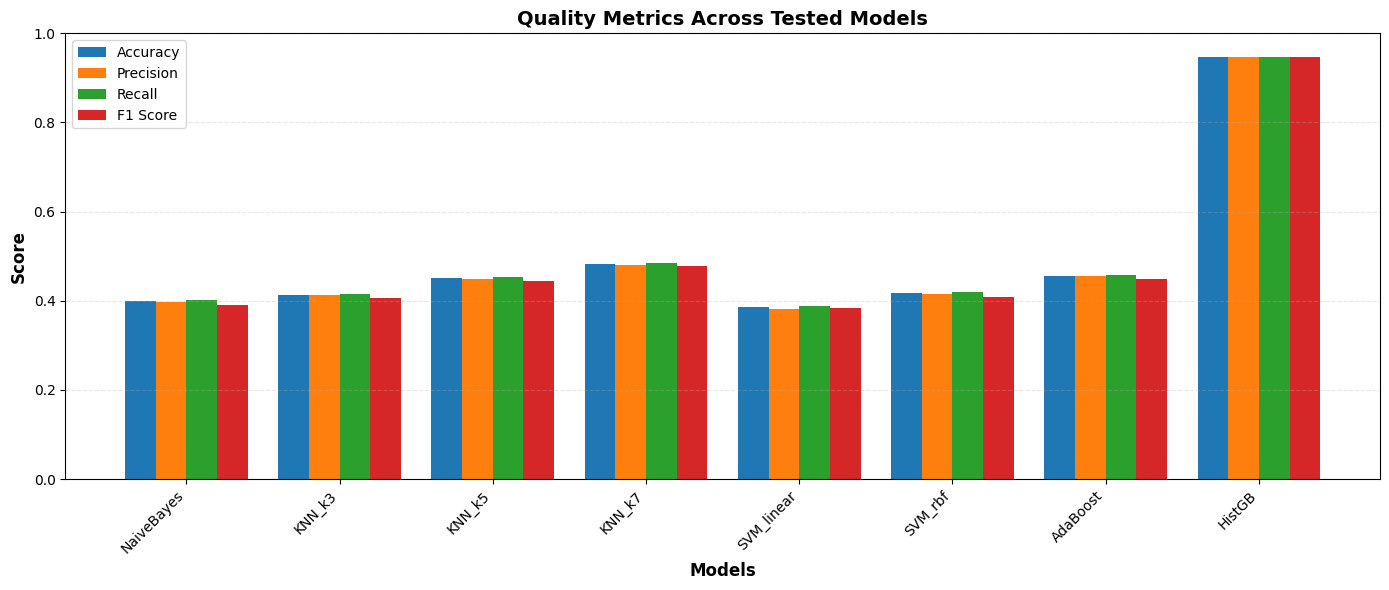

In [11]:
# ============================================================
# VISUALIZATION - MODEL COMPARISON CHART
# ============================================================
# Prepare data for grouped bar chart
x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_Score_macro']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, results_df[metric], width, label=metric_labels[i])

# Customize plot
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Quality Metrics Across Tested Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

plt.tight_layout()

# Save figure
fig_path = os.path.join("..", "results", "janhavi_model_comparison.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {fig_path}")
print(f"File size: {os.path.getsize(fig_path)} bytes")

plt.show()

Efficiency plot saved to: ..\results\janhavi_efficiency_plot.png
File size: 161345 bytes

Efficiency Analysis:
Fastest Inference: NaiveBayes (0.001997s)
Fastest Training: NaiveBayes (0.015729s)


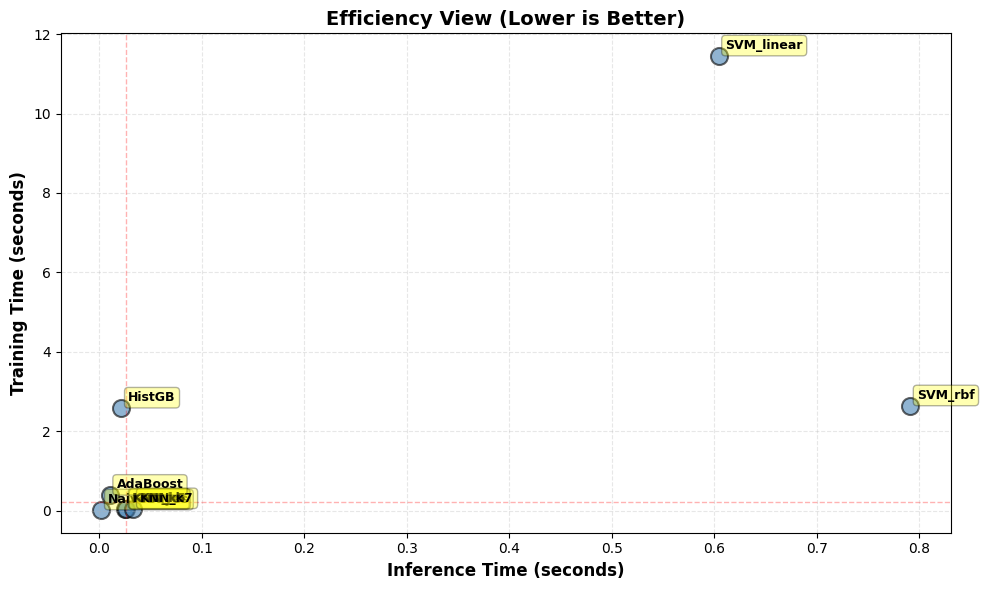

In [12]:
# ============================================================
# VISUALIZATION - EFFICIENCY PLOT
# ============================================================
# Create scatter plot: Training Time vs Inference Time
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(results_df['Inference_Time_s'], results_df['Training_Time_s'], 
           s=150, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1.5)

# Add labels for each point
for idx, row in results_df.iterrows():
    ax.annotate(row['Model'], 
                xy=(row['Inference_Time_s'], row['Training_Time_s']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Customize plot
ax.set_xlabel('Inference Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Efficiency View (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add quadrant lines to visualize "best" region (lower left)
ax.axhline(y=results_df['Training_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=results_df['Inference_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()

# Save figure
eff_path = os.path.join("..", "results", "janhavi_efficiency_plot.png")
plt.savefig(eff_path, dpi=300, bbox_inches='tight')
print(f"Efficiency plot saved to: {eff_path}")
print(f"File size: {os.path.getsize(eff_path)} bytes")

# Print efficiency insights
print("\nEfficiency Analysis:")
fastest_inference = results_df.loc[results_df['Inference_Time_s'].idxmin()]
fastest_training = results_df.loc[results_df['Training_Time_s'].idxmin()]
print(f"Fastest Inference: {fastest_inference['Model']} ({fastest_inference['Inference_Time_s']:.6f}s)")
print(f"Fastest Training: {fastest_training['Model']} ({fastest_training['Training_Time_s']:.6f}s)")

plt.show()

In [13]:
# ============================================================
# SELECT BEST MODEL & RETRAIN
# ============================================================
# Find model with highest F1 score
best_model_idx = results_df['F1_Score_macro'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1_score = results_df.loc[best_model_idx, 'F1_Score_macro']

print(f"Best Model (by F1 Score): {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")

# Retrieve the best model from models dictionary
best_model = models[best_model_name]

# Retrain on reduced training data
print("\nRetraining best model on reduced training data...")
retrain_start = time.time()
best_model.fit(X_train_reduced_scaled, y_train)
retrain_time = time.time() - retrain_start

print(f"Retraining completed in {retrain_time:.4f}s")

# Validate on test set
y_pred_best = best_model.predict(X_test_reduced_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
best_recall = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
best_f1_retrained = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

print(f"\nRetrained Model Performance on Test Set:")
print(f"  Accuracy:  {best_accuracy:.4f}")
print(f"  Precision: {best_precision:.4f}")
print(f"  Recall:    {best_recall:.4f}")
print(f"  F1 Score:  {best_f1_retrained:.4f}")


Best Model (by F1 Score): HistGB
F1 Score: 0.9470

Retraining best model on reduced training data...


Retraining completed in 0.4462s

Retrained Model Performance on Test Set:
  Accuracy:  0.9468
  Precision: 0.9469
  Recall:    0.9471
  F1 Score:  0.9470


In [14]:
# ============================================================
# SAVE BEST MODEL
# ============================================================
# Save the best trained model to disk using joblib
model_path = os.path.join("..", "models", "feature_selector.pkl")

# Create models directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save the best model
joblib.dump(best_model, model_path)
print(f"Best Model saved to: {model_path}")
print(f"Model type: {best_model_name}")
print(f"File size: {os.path.getsize(model_path)} bytes")

# Verify the save by loading and testing
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test_reduced_scaled)
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)
print(f"\nVerification: Loaded model accuracy on test set: {loaded_accuracy:.4f}")
print("✓ Model successfully saved and verified!")


Best Model saved to: ..\models\feature_selector.pkl
Model type: HistGB
File size: 1087248 bytes

Verification: Loaded model accuracy on test set: 0.9468
✓ Model successfully saved and verified!


In [15]:
# ============================================================
# FEATURE SELECTION SUMMARY (FINAL)
# ============================================================
selector = {
    "method": "mutual_info_top5",
    "selected_features": top_5_features,
    "n_selected": len(top_5_features),
}

print("Selected", selector["n_selected"], "features out of", X_train.shape[1])
print("Selected features:")
print(selector["selected_features"])

selected_features_df = pd.DataFrame({
    "feature": top_5_features,
    "selection_score": mi_df.set_index("Feature").loc[top_5_features, "MI_Score"].values,
}).sort_values("selection_score", ascending=False)

print("\nSelected feature table:")
print(selected_features_df.to_string(index=False))

Selected 5 features out of 21
Selected features:
['country', 'water_Salinity (ppt)', 'water_SecchiDepth (m)', 'water_WaterTemp (C)', 'year']

Selected feature table:
              feature  selection_score
              country         0.665832
 water_Salinity (ppt)         0.029611
water_SecchiDepth (m)         0.025388
  water_WaterTemp (C)         0.022938
                 year         0.022445


In [16]:
# ============================================================
# SHAP / FEATURE IMPORTANCE (PERMUTATION + OPTIONAL SHAP)
# ============================================================
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test_reduced_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)

importances = pd.DataFrame({
    "feature": X_test_reduced_scaled.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top feature importances:")
print(importances.head(10).to_string(index=False))

top_row = importances.iloc[0]
print(
    f"\nMost influential parameter (permutation): {top_row['feature']} "
    f"(importance={float(top_row['importance_mean']):.6f})"
)

if hasattr(best_model, "feature_importances_") and hasattr(best_model, "predict"):
    try:
        shap_out = os.path.join("..", "results", "genomic_shap_summary.png")
        explainer = shap.Explainer(best_model, X_train_reduced_scaled)
        shap_values = explainer(X_test_reduced_scaled)

        # Global SHAP importance summary for audit/reporting
        shap.plots.beeswarm(shap_values, max_display=10, show=False)
        plt.title("SHAP Summary — Genomic Best Model")
        plt.tight_layout()
        plt.savefig(shap_out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP summary plot -> {shap_out}")

        sv = np.asarray(shap_values.values, dtype=float)
        if sv.ndim == 3:
            cls_idx = 0
            try:
                pred_label = best_model.predict(X_test_reduced_scaled.iloc[[0]])[0]
                classes = list(getattr(best_model, "classes_", []))
                if pred_label in classes:
                    cls_idx = classes.index(pred_label)
            except Exception:
                cls_idx = 0
            cls_idx = int(min(max(cls_idx, 0), sv.shape[2] - 1))
            abs_imp = np.mean(np.abs(sv[:, :, cls_idx]), axis=0)
        elif sv.ndim == 2:
            abs_imp = np.mean(np.abs(sv), axis=0)
        else:
            abs_imp = np.abs(np.ravel(sv))

        if len(abs_imp) > 0:
            i = int(np.argmax(abs_imp))
            feature_name = str(X_test_reduced_scaled.columns[min(i, len(X_test_reduced_scaled.columns) - 1)])
            print(
                f"Most influential parameter (SHAP): {feature_name} "
                f"(|mean SHAP|={float(abs_imp[i]):.6f})"
            )
    except Exception as exc:
        print(f"SHAP summary skipped: {exc}")
else:
    print("SHAP summary skipped: model type is not tree-based.")

Top feature importances:
              feature  importance_mean  importance_std
              country         0.596196        0.007496
                 year         0.218657        0.006181
 water_Salinity (ppt)         0.000108        0.001887
water_SecchiDepth (m)        -0.000864        0.000582
  water_WaterTemp (C)        -0.000908        0.000997

Most influential parameter (permutation): country (importance=0.596196)
SHAP summary skipped: model type is not tree-based.


In [17]:
# ============================================================
# SAVE FEATURE SELECTOR & IMPORTANCE (FINAL)
# ============================================================
MODEL_PATH = os.path.join("..", "models", "feature_selector.pkl")
RESULT_PATH = os.path.join("..", "results", "genomic_feature_importance.csv")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)

joblib.dump(best_model, MODEL_PATH)
print(f"Feature selector saved -> {MODEL_PATH}")

importances.to_csv(RESULT_PATH, index=False)
print(f"Feature importance saved -> {RESULT_PATH}")

_loaded = joblib.load(MODEL_PATH)
print("Reload check:", type(_loaded))

Feature selector saved -> ..\models\feature_selector.pkl
Feature importance saved -> ..\results\genomic_feature_importance.csv
Reload check: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


In [18]:
import joblib

model = joblib.load("../models/feature_selector.pkl")
print("Model loaded successfully:", type(model))

Model loaded successfully: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


## Best Model Architecture (Genomic Track) - HistGradientBoostingClassifier

### Architecture Diagram
Input features -> Numeric matrix alignment -> HistGB -> Class output -> SHAP interpretation

```mermaid
flowchart LR
    A[Input: country + water salinity/secchi/temp + year] --> B[Processing: factorize categoricals + numeric conversion + NaN handling]
    B --> C[Model: HistGradientBoostingClassifier]
    C --> D[Output: Low / Medium / High genomic class signal]
    D --> E[Explainability: SHAP local impacts + fallback influence]
```

### 1. Input Layer
- Source dataset: `final_dataset.csv`.
- Target: production quantiles into Low/Medium/High classes.
- Current model feature schema (strict): `country`, `water_Salinity (ppt)`, `water_SecchiDepth (m)`, `water_WaterTemp (C)`, `year`.

### 2. Processing Layer
- Object features are factorized to numeric codes.
- Final matrix converted to numeric and NaN-filled.
- Stratified train/test split with `random_state=42`.

### 3. Model Layer (Best Performing)
- Estimator: `HistGradientBoostingClassifier`.
- Training strategy: histogram-based gradient boosting on numeric matrix.
- Why selected: strongest available genomic-track multiclass metrics.

### 4. Output Layer
- Predicted class: Low / Medium / High.
- Used as genomic signal for downstream decision context.

### 5. Explainability Layer (SHAP)
- SHAP values computed on the numeric genomic-context feature space.
- Top absolute impacts identify most influential genomic/context parameters.
- Fallback influence uses model-compatible delta-based approximation if SHAP path fails.

### 6. Limitations
- Factorization of categories imposes ordinal-like numeric codes.
- Genomic signal is predictive, not mechanistic proof.
- Model cannot identify exact biological causal pathway from sequence-level changes.
- Performance and importance can shift with new populations or unseen cohorts.